# Baseline Models Training
#### GRU-Only | CNN+GRU
Trains and saves checkpoints for all three baseline models.
Results are compared against TCN in `07_testing_comparison.ipynb`.

In [1]:
import sys, os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings('ignore')

import torch
import numpy as np
import matplotlib.pyplot as plt
import json, time, yaml
from pathlib import Path

from src.models import GRUClassifier, CNNGRUClassifier, FocalLoss
from src.eval.trainer import run_epoch
from src.data.dataset import build_split_dataset, EEGDataset, build_train_loader, build_eval_loader

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_DIR  = Path('checkpoints'); CKPT_DIR.mkdir(exist_ok=True)
RESULTS_DIR = Path('results/baselines'); RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'Results: {RESULTS_DIR}')

Device : cuda
PyTorch: 2.10.0+cu128
Results: results/baselines


In [2]:
with open('config.yaml') as f:
    cfg = yaml.safe_load(f)

_raw  = cfg['data']['raw_dir']
_ch   = cfg['data']['channels']
_wsec = cfg['data']['window_size']
_fs   = cfg['data']['sample_rate']
_ov   = cfg['data']['overlap']
_szt  = cfg['data']['seizure_threshold']
_bpl  = cfg['preprocessing']['bandpass_low']
_bph  = cfg['preprocessing']['bandpass_high']
_ntch = cfg['preprocessing']['notch_freq']
_seed = cfg['training']['seed']
_bs   = cfg['training']['batch_size']

# Save to /tmp — no quota, survives the session
CACHE_DIR = '/tmp/neuroscribe_cache'
os.makedirs(CACHE_DIR, exist_ok=True)


def _load_split(split, pids):
    cache_path = os.path.join(CACHE_DIR, f'{split}_subsampled.npz')
    if os.path.exists(cache_path):
        print(f'[{split}] Loading from /tmp cache...')
        d = np.load(cache_path)
        return EEGDataset(d['windows'], d['labels'], d['patient_ids'])

    print(f'[{split}] Building from raw EDF (first run only)...')
    ds = build_split_dataset(
        raw_dir=_raw, patient_ids=pids, split_name=split,
        target_channels=_ch, window_size_sec=_wsec, overlap=_ov,
        seizure_threshold=_szt, bandpass_low=_bpl, bandpass_high=_bph,
        notch_freq=_ntch, sample_rate=_fs,
        processed_dir=None, use_cache=False,
    )
    np.random.seed(_seed)
    s_idx  = np.where(ds.labels == 1)[0]
    ns_all = np.where(ds.labels == 0)[0]
    ns_idx = np.random.choice(ns_all, min(len(s_idx) * 5, len(ns_all)), replace=False)
    idx    = np.random.permutation(np.concatenate([s_idx, ns_idx]))
    ds     = EEGDataset(ds.windows[idx], ds.labels[idx], ds.patient_ids[idx])
    np.savez_compressed(cache_path, windows=ds.windows, labels=ds.labels, patient_ids=ds.patient_ids)
    print(f'  Cached → {cache_path}')
    print(f'  {len(ds):,} windows  seizure={ds.n_seizure:,} ({ds.seizure_fraction:.2%})')
    return ds


train_ds = _load_split('train', cfg['splits']['train_patients'])
val_ds   = _load_split('val',   cfg['splits']['val_patients'])
test_ds  = _load_split('test',  cfg['splits']['test_patients'])

train_loader = build_train_loader(train_ds, batch_size=_bs, seed=_seed)
val_loader   = build_eval_loader(val_ds,   batch_size=_bs * 2)
test_loader  = build_eval_loader(test_ds,  batch_size=_bs * 2)

meta = {
    'train': {'n': len(train_ds), 'n_seizure': train_ds.n_seizure, 'seizure_frac': train_ds.seizure_fraction},
    'val':   {'n': len(val_ds),   'n_seizure': val_ds.n_seizure,   'seizure_frac': val_ds.seizure_fraction},
    'test':  {'n': len(test_ds),  'n_seizure': test_ds.n_seizure,  'seizure_frac': test_ds.seizure_fraction},
    'batch_size': _bs,
}
print('DataLoaders ready.')
print(f'  Train : {meta["train"]["n"]:,}  seizure: {meta["train"]["n_seizure"]:,} ({meta["train"]["seizure_frac"]:.2%})')
print(f'  Val   : {meta["val"]["n"]:,}  seizure: {meta["val"]["n_seizure"]:,} ({meta["val"]["seizure_frac"]:.2%})')
print(f'  Test  : {meta["test"]["n"]:,}  seizure: {meta["test"]["n_seizure"]:,} ({meta["test"]["seizure_frac"]:.2%})')

[train] Loading from /tmp cache...
[val] Loading from /tmp cache...
[test] Loading from /tmp cache...
DataLoaders ready.
  Train : 24,378  seizure: 4,063 (16.67%)
  Val   : 2,226  seizure: 371 (16.67%)
  Test  : 3,132  seizure: 522 (16.67%)


---
## Model Definitions

In [3]:
BASELINES = {
    # bidirectional, 2-layer, hidden=128 — enough capacity to learn
    'GRU-Only' : GRUClassifier(
        n_channels=23, hidden_size=128, num_layers=2,
        bidirectional=True, dropout=0.65,
    ),
    # full CNN + hidden=128 GRU
    'CNN+GRU'  : CNNGRUClassifier(
        n_channels=23,
        cnn_filters=[32, 64, 128],
        hidden_size=128,
        dropout=0.65,
    ),
}

print('Baseline Architectures\n' + '='*45)
for name, m in BASELINES.items():
    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {name:<12} : {params:>9,} parameters')

Baseline Architectures
  GRU-Only     :   414,466 parameters
  CNN+GRU      :   535,746 parameters


---
## Training Loop

In [4]:
# Delete old baseline checkpoints to force retraining with new smaller architectures
for name in ['GRU_Only', 'CNN_GRU']:
    for suffix in ['_best.pt', '_log.json']:
        p = CKPT_DIR / f'{name}{suffix}'
        if p.exists():
            p.unlink()
            print(f'Deleted {p}')

Deleted checkpoints/GRU_Only_best.pt
Deleted checkpoints/GRU_Only_log.json
Deleted checkpoints/CNN_GRU_best.pt
Deleted checkpoints/CNN_GRU_log.json


In [5]:
def train_model(name, model, train_loader, val_loader, device,
                lr=5e-4, weight_decay=2e-2, max_epochs=20, patience=3):
    ckpt_path = CKPT_DIR / f'{name.replace("+","_").replace("-","_")}_best.pt'
    log_path  = CKPT_DIR / f'{name.replace("+","_").replace("-","_")}_log.json'

    model = model.to(device)

    if ckpt_path.exists() and log_path.exists():
        print(f'  [{name}] Loading saved checkpoint.')
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        return json.load(open(log_path))

    criterion = FocalLoss(alpha=0.85, gamma=2.0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

    history = {'train_loss':[], 'train_f1':[], 'val_loss':[], 'val_f1':[], 'best_epoch':0}
    best_val_f1, no_improve = 0.0, 0

    print(f'  [{name}] Training up to {max_epochs} epochs...')
    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr = run_epoch(model, train_loader, criterion, optimizer, device, threshold=0.5)
        vl = run_epoch(model, val_loader,   criterion, None,      device, threshold=0.5)
        scheduler.step()

        history['train_loss'].append(tr['loss']); history['train_f1'].append(tr['f1'])
        history['val_loss'].append(vl['loss']);   history['val_f1'].append(vl['f1'])

        print(f'    Ep {epoch:02d}/{max_epochs}  '
              f'train loss={tr["loss"]:.4f} f1={tr["f1"]:.4f}  '
              f'val loss={vl["loss"]:.4f} f1={vl["f1"]:.4f}  ({time.time()-t0:.0f}s)')

        if vl['f1'] > best_val_f1:
            best_val_f1 = vl['f1']; history['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path); no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'    Early stop (best epoch {history["best_epoch"]})')
                break

    json.dump(history, open(log_path, 'w'), indent=2)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    print(f'    Best Val F1={best_val_f1:.4f} → {ckpt_path.name}')
    return history

histories = {}

---
## Train GRU-Only

In [6]:
print('GRU-Only\n' + '='*45)
histories['GRU-Only'] = train_model('GRU-Only', BASELINES['GRU-Only'], train_loader, val_loader, DEVICE)

GRU-Only
  [GRU-Only] Training up to 20 epochs...
    Ep 01/20  train loss=0.0582 f1=0.6636  val loss=0.0571 f1=0.2857  (80s)
    Ep 02/20  train loss=0.0569 f1=0.6641  val loss=0.0564 f1=0.2857  (81s)
    Ep 03/20  train loss=0.0568 f1=0.6671  val loss=0.0573 f1=0.2857  (74s)
    Ep 04/20  train loss=0.0568 f1=0.6643  val loss=0.0578 f1=0.2857  (75s)
    Early stop (best epoch 1)
    Best Val F1=0.2857 → GRU_Only_best.pt


---
## Train CNN+GRU

In [7]:
print('CNN+GRU\n' + '='*45)
histories['CNN+GRU'] = train_model('CNN+GRU', BASELINES['CNN+GRU'], train_loader, val_loader, DEVICE)

CNN+GRU
  [CNN+GRU] Training up to 20 epochs...
    Ep 01/20  train loss=0.0351 f1=0.7566  val loss=0.0556 f1=0.3199  (45s)
    Ep 02/20  train loss=0.0263 f1=0.8185  val loss=0.0299 f1=0.6411  (45s)
    Ep 03/20  train loss=0.0259 f1=0.8180  val loss=0.0285 f1=0.6470  (44s)
    Ep 04/20  train loss=0.0263 f1=0.8170  val loss=0.0317 f1=0.6623  (44s)
    Ep 05/20  train loss=0.0246 f1=0.8268  val loss=0.0267 f1=0.6478  (43s)
    Ep 06/20  train loss=0.0242 f1=0.8324  val loss=0.0294 f1=0.5079  (47s)
    Ep 07/20  train loss=0.0246 f1=0.8266  val loss=0.0296 f1=0.4955  (46s)
    Early stop (best epoch 4)
    Best Val F1=0.6623 → CNN_GRU_best.pt


---
## Training Curves

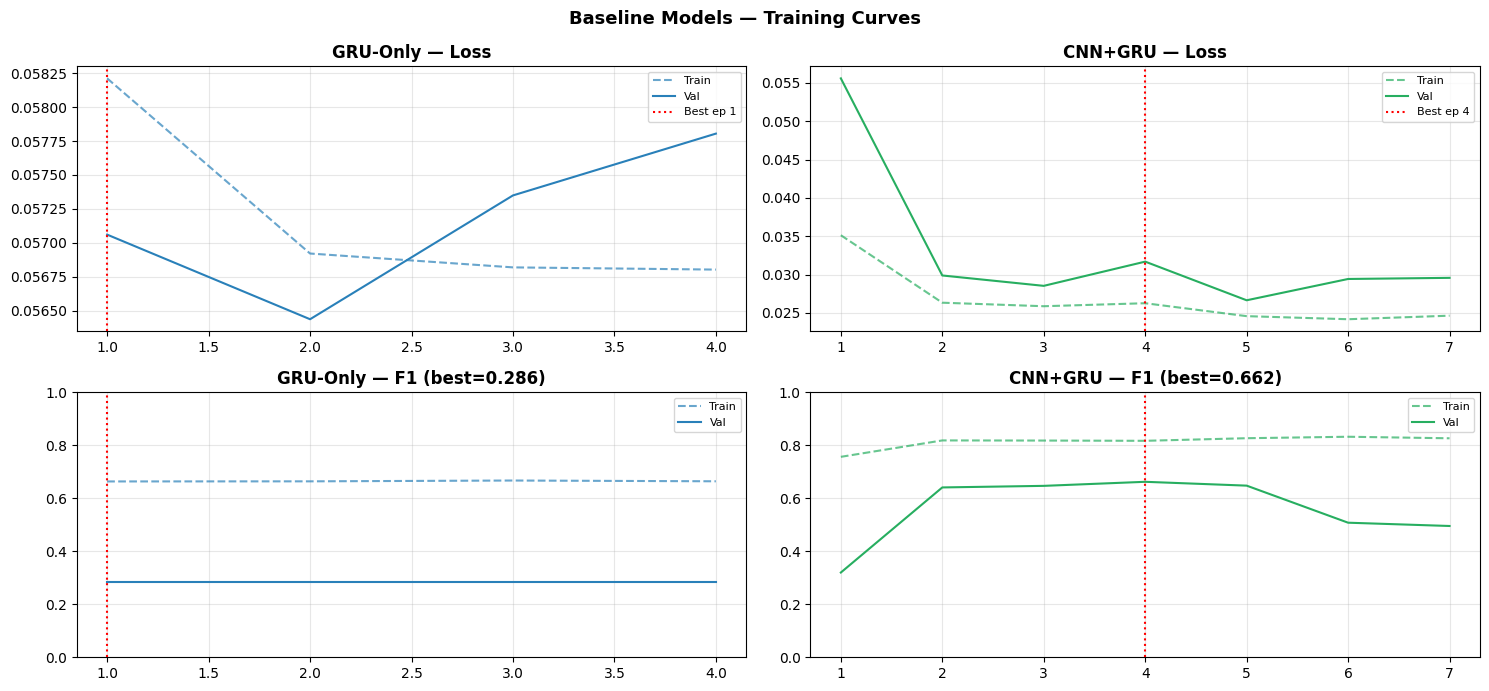

Saved → results/baselines/baseline_training_curves.png


In [8]:
colors = {'GRU-Only':'#2980b9', 'CNN+GRU':'#27ae60'}
fig, axes = plt.subplots(2, 2, figsize=(15, 7))

for col, (name, hist) in enumerate(histories.items()):
    epochs = range(1, len(hist['train_loss'])+1)
    c = colors[name]
    ax = axes[0, col]
    ax.plot(epochs, hist['train_loss'], '--', color=c, alpha=0.7, label='Train')
    ax.plot(epochs, hist['val_loss'],   '-',  color=c,            label='Val')
    ax.axvline(hist['best_epoch'], color='red', linestyle=':', label=f'Best ep {hist["best_epoch"]}')
    ax.set_title(f'{name} — Loss', fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[1, col]
    ax.plot(epochs, hist['train_f1'], '--', color=c, alpha=0.7, label='Train')
    ax.plot(epochs, hist['val_f1'],   '-',  color=c,            label='Val')
    ax.axvline(hist['best_epoch'], color='red', linestyle=':')
    ax.set_title(f'{name} — F1 (best={max(hist["val_f1"]):.3f})', fontweight='bold')
    ax.set_ylim(0, 1); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('Baseline Models — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'baseline_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {RESULTS_DIR}/baseline_training_curves.png')

In [9]:
print('Checkpoint Summary')
print('='*50)
for f in sorted(CKPT_DIR.iterdir()):
    print(f'  {f.name:<45}  {f.stat().st_size/1024:>7.1f} KB')

print('\nBaseline Training Summary:')
summary = {}
for name, hist in histories.items():
    best_f1 = max(hist['val_f1'])
    summary[name] = {'epochs': len(hist['train_loss']), 'best_epoch': hist['best_epoch'], 'best_val_f1': best_f1}
    print(f'  {name:<12}  epochs={len(hist["train_loss"]):>3}  '
          f'best_epoch={hist["best_epoch"]:>3}  best_val_f1={best_f1:.4f}')

# Save summary JSON
with open(RESULTS_DIR / 'baseline_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(f'\nSaved → {RESULTS_DIR}/baseline_summary.json')

Checkpoint Summary
  CNN_GRU_best.pt                                 2105.5 KB
  CNN_GRU_log.json                                   0.8 KB
  GRU_Only_best.pt                                1623.2 KB
  GRU_Only_log.json                                  0.5 KB
  TCN_best.pt                                     3149.3 KB
  TCN_improved_best.pt                            3150.3 KB
  TCN_improved_log.json                              5.4 KB
  TCN_log.json                                       4.3 KB

Baseline Training Summary:
  GRU-Only      epochs=  4  best_epoch=  1  best_val_f1=0.2857
  CNN+GRU       epochs=  7  best_epoch=  4  best_val_f1=0.6623

Saved → results/baselines/baseline_summary.json
